<a href="https://colab.research.google.com/github/muaaz-tahir/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muaaz-tahir/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [30]:
import duckdb
import pandas as pd
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"
print("Connected. Ready to query the full warehouse.")

Connected. Ready to query the full warehouse.


## 1. Question

*The research question and the decision it supports.*



**Research question:** Given limited review capacity, which pages should the content team check first, refresh, expand, or leave alone, and can a trained model rank them more accurately than a hand-written rule?

**Decision this supports:** which pages a content team reviews first each cycle, when they cannot review every page.

**Why this question:** Week 1 showed a simple fixed rule ("old + popular") catches almost none of the pages that actually need review. Week 4 built a hand-written rule with three reason codes (QUICK_WIN, CTR_FIX, REFRESH) as a first attempt. This capstone tests whether a trained model, using the same signals, can rank pages more accurately than that rule, validated honestly on the same data split.

In [31]:
print("Question: Given limited review capacity, which pages should the")
print("content team check first, and can a trained model rank them")
print("better than the hand-written baseline rule from Week 4?")

Question: Given limited review capacity, which pages should the
content team check first, and can a trained model rank them
better than the hand-written baseline rule from Week 4?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [32]:
train_query = f"""
SELECT
    client_hash_id,
    content_hash_id,
    month,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(gsc_sum_position) AS sum_position
FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-0[1-3]/*.parquet')
WHERE gsc_data_available = true
GROUP BY client_hash_id, content_hash_id, month
"""

train_monthly = con.sql(train_query).df()
print(f"Rows: {len(train_monthly)}")
train_monthly.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 451841


,client_hash_id,content_hash_id,month,impressions,clicks,sum_position
0,client_62f4a7e64f5e0096,content_80071808216aef39,2026-01,52196.0,90.0,254021.0
1,client_62f4a7e64f5e0096,content_440bb5eb2a519088,2026-01,3214.0,28.0,10964.0
2,client_62f4a7e64f5e0096,content_17ff914d33201392,2026-01,229.0,0.0,898.0
3,client_62f4a7e64f5e0096,content_f67e870cf4ed24f0,2026-01,7017.0,41.0,17117.0
4,client_62f4a7e64f5e0096,content_a1347678bacc57fd,2026-01,4160.0,11.0,31252.0


In [33]:
test_query = f"""
SELECT
    client_hash_id,
    content_hash_id,
    month,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(gsc_sum_position) AS sum_position
FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-0[4-6]/*.parquet')
WHERE gsc_data_available = true
GROUP BY client_hash_id, content_hash_id, month
"""

test_monthly = con.sql(test_query).df()
print(f"Rows: {len(test_monthly)}")
test_monthly.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 641306


,client_hash_id,content_hash_id,month,impressions,clicks,sum_position
0,client_62f4a7e64f5e0096,content_f1c085e5ea530266,2026-04,64.0,0.0,1042.0
1,client_62f4a7e64f5e0096,content_82f4df1a7531638c,2026-04,15.0,0.0,14.0
2,client_62f4a7e64f5e0096,content_c4901b51a12b1c3b,2026-04,81.0,0.0,764.0
3,client_62f4a7e64f5e0096,content_ecb932abf0674642,2026-04,31.0,0.0,196.0
4,client_62f4a7e64f5e0096,content_64706c8afebebb8c,2026-04,131.0,1.0,1014.0


In [34]:
train_total = con.sql(f"""
    SELECT COUNT(*) as n
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-0[1-3]/*.parquet')
""").df()['n'][0]

test_total = con.sql(f"""
    SELECT COUNT(*) as n
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-0[4-6]/*.parquet')
""").df()['n'][0]

print(f"Train period total rows (before GSC filter): {train_total}")
print(f"Train period rows kept: {len(train_monthly)} page-months")
print(f"Test period total rows (before GSC filter): {test_total}")
print(f"Test period rows kept: {len(test_monthly)} page-months")

Train period total rows (before GSC filter): 25087303
Train period rows kept: 451841 page-months
Test period total rows (before GSC filter): 33806178
Test period rows kept: 641306 page-months




**Release:** FlyRank internship-warehouse, `fact_content_daily_performance` table, monthly partitioned parquet files on Hugging Face.

**Train window:** January–March 2026 (Q1), aggregated to one row per page per month. 25,087,303 raw daily rows in this window, collapsing to 451,841 page-month rows with real, usable GSC data.

**Test window:** April–June 2026 (Q2), same aggregation. 33,806,178 raw daily rows, collapsing to 641,306 page-month rows with real, usable GSC data.

**Why this split:** train and test come from fully separate calendar quarters, so the model is validated on months it has never seen, a genuine time-aware split rather than a random shuffle that could leak information across time.

**What was excluded and why:**
- Rows where `gsc_data_available = false` were dropped in both periods. These are placeholder rows with no real search data, keeping them would silently bias every metric toward zero.
- No FlyRank product decision flags exist in this table, so none were used as features (confirmed by checking `df.columns` in Week 3).
- No client names, domains, URLs, or private query text are used anywhere, only hashed `client_hash_id` and `content_hash_id`.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [35]:
def build_features(monthly_df):
    totals = monthly_df.groupby(['client_hash_id', 'content_hash_id']).agg(
        total_impressions=('impressions', 'sum'),
        total_clicks=('clicks', 'sum'),
        sum_position=('sum_position', 'sum')
    ).reset_index()
    totals['avg_position'] = totals['sum_position'] / totals['total_impressions']
    totals['ctr'] = totals['total_clicks'] / totals['total_impressions']
    return totals.dropna(subset=['avg_position', 'ctr'])

train_features = build_features(train_monthly)
test_features = build_features(test_monthly)

print(f"Train pages: {len(train_features)}")
print(f"Test pages: {len(test_features)}")
train_features.head()

Train pages: 203074
Test pages: 271046


,client_hash_id,content_hash_id,total_impressions,total_clicks,sum_position,avg_position,ctr
0,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,1.0,0.0,9.0,9.000000,0.000000
1,client_0797ff3a1fc9a6a5,content_0317b24cc1ff5c5d,5.0,0.0,52.0,10.400000,0.000000
2,client_0797ff3a1fc9a6a5,content_04c67f3541177192,858.0,6.0,12689.0,14.789044,0.006993
3,client_0797ff3a1fc9a6a5,content_05acc92c165f4386,296.0,0.0,2865.0,9.679054,0.000000
4,client_0797ff3a1fc9a6a5,content_0b33d8960857ad90,36.0,0.0,434.0,12.055556,0.000000


In [36]:
def add_trend(monthly_df, features_df, first_month, last_month):
    first = monthly_df[monthly_df['month'] == first_month].groupby(
        ['client_hash_id', 'content_hash_id'])['impressions'].sum()
    last = monthly_df[monthly_df['month'] == last_month].groupby(
        ['client_hash_id', 'content_hash_id'])['impressions'].sum()

    features_df = features_df.set_index(['client_hash_id', 'content_hash_id'])
    features_df['impr_first_month'] = first
    features_df['impr_last_month'] = last
    features_df = features_df.reset_index()

    features_df['impr_first_month'] = features_df['impr_first_month'].fillna(0)
    features_df['impr_last_month'] = features_df['impr_last_month'].fillna(0)

    features_df['trend_pct'] = (
        (features_df['impr_last_month'] - features_df['impr_first_month'])
        / features_df['impr_first_month'].replace(0, pd.NA)
    )
    return features_df

train_features = add_trend(train_monthly, train_features, '2026-01', '2026-03')
test_features = add_trend(test_monthly, test_features, '2026-04', '2026-06')

print(train_features[['total_impressions', 'impr_first_month', 'impr_last_month', 'trend_pct']].head(10))

   total_impressions  impr_first_month  impr_last_month trend_pct
0                1.0               0.0              1.0      <NA>
1                5.0               5.0              0.0      -1.0
2              858.0             281.0            331.0  0.177936
3              296.0             126.0             33.0 -0.738095
4               36.0              28.0              0.0      -1.0
5              377.0             111.0            145.0  0.306306
6              967.0             332.0            461.0  0.388554
7                1.0               0.0              1.0      <NA>
8               67.0              28.0             39.0  0.392857
9              724.0             328.0            232.0 -0.292683


In [37]:
def add_label(features_df):
    features_df['needs_review'] = (
        (features_df['trend_pct'] <= -0.10) &
        (features_df['total_impressions'] >= 100)
    ).astype(int)
    return features_df

train_features = add_label(train_features)
test_features = add_label(test_features)

print("Train label distribution:")
print(train_features['needs_review'].value_counts())
print("\nTest label distribution:")
print(test_features['needs_review'].value_counts())

Train label distribution:
needs_review
0    179937
1     23137
Name: count, dtype: int64

Test label distribution:
needs_review
0    173373
1     97673
Name: count, dtype: int64


In [38]:
def add_bucket_features(df):
    def position_bucket(p):
        if p <= 3: return '1_top3'
        elif p <= 10: return '2_top10'
        elif p <= 20: return '3_pos11to20'
        elif p <= 50: return '4_pos21to50'
        else: return '5_beyond50'
    df['position_bucket'] = df['avg_position'].apply(position_bucket)
    df['bucket_mean_ctr'] = df.groupby('position_bucket')['ctr'].transform('mean')
    return df

train_features = add_bucket_features(train_features)
test_features = add_bucket_features(test_features)

print(train_features[['position_bucket', 'bucket_mean_ctr']].drop_duplicates())

    position_bucket  bucket_mean_ctr
0           2_top10         0.006082
1       3_pos11to20         0.003664
10      4_pos21to50         0.002429
61       5_beyond50         0.001091
102          1_top3         0.012311


In [39]:
def apply_baseline_rule(df, volume_min):
    def assign_reason(row):
        if row['position_bucket'] == '3_pos11to20' and row['total_impressions'] >= volume_min:
            return 'QUICK_WIN'
        elif row['position_bucket'] in ['1_top3', '2_top10'] and row['ctr'] < row['bucket_mean_ctr'] and row['total_impressions'] >= volume_min:
            return 'CTR_FIX'
        elif pd.notna(row['trend_pct']) and row['trend_pct'] <= -0.10 and row['total_impressions'] >= volume_min:
            return 'REFRESH'
        else:
            return 'MONITOR'
    df['baseline_reason'] = df.apply(assign_reason, axis=1)
    df['baseline_flag'] = (df['baseline_reason'] != 'MONITOR').astype(int)
    return df

VOLUME_MIN = train_features['total_impressions'].median()
train_features = apply_baseline_rule(train_features, VOLUME_MIN)
test_features = apply_baseline_rule(test_features, VOLUME_MIN)

print(f"Volume threshold (from train median): {VOLUME_MIN}")
print(train_features['baseline_reason'].value_counts())

Volume threshold (from train median): 222.0
baseline_reason
MONITOR      124103
CTR_FIX       53377
QUICK_WIN     21402
REFRESH        4192
Name: count, dtype: int64


In [40]:
train_features['trend_pct'] = pd.to_numeric(train_features['trend_pct'], errors='coerce')
test_features['trend_pct'] = pd.to_numeric(test_features['trend_pct'], errors='coerce')

print(train_features['trend_pct'].dtype)
print(test_features['trend_pct'].dtype)

float64
float64


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

feature_cols = ['avg_position', 'ctr', 'total_impressions', 'trend_pct', 'bucket_mean_ctr']

X_train = train_features[feature_cols].copy()
y_train = train_features['needs_review']

X_test = test_features[feature_cols].copy()
y_test = test_features['needs_review']

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_imputed, y_train)

train_features['model_score'] = model.predict_proba(X_train_imputed)[:, 1]
test_features['model_score'] = model.predict_proba(X_test_imputed)[:, 1]

print("Model trained.")
print(f"Features used: {feature_cols}")
print(f"Coefficients: {dict(zip(feature_cols, model.coef_[0].round(3)))}")

Model trained.
Features used: ['avg_position', 'ctr', 'total_impressions', 'trend_pct', 'bucket_mean_ctr']
Coefficients: {'avg_position': np.float64(-0.011), 'ctr': np.float64(-12.607), 'total_impressions': np.float64(0.0), 'trend_pct': np.float64(-3.957), 'bucket_mean_ctr': np.float64(-0.257)}


In [42]:
print("Leakage check for model features:")
print("- trend_pct compares first vs last month within the SAME quarter, no future quarter data used.")
print("- needs_review label uses trend_pct and total_impressions, both computed only from data")
print("  already available at the time of scoring, no outcome from a later period used as a feature.")
print("- bucket_mean_ctr and VOLUME_MIN were computed from TRAIN only, then applied unchanged to test,")
print("  test period numbers never influenced these values.")
print("- Model was trained only on train_features (Q1 2026), evaluated only on test_features (Q2 2026),")
print("  fully separate calendar quarters.")

Leakage check for model features:
- trend_pct compares first vs last month within the SAME quarter, no future quarter data used.
- needs_review label uses trend_pct and total_impressions, both computed only from data
  already available at the time of scoring, no outcome from a later period used as a feature.
- bucket_mean_ctr and VOLUME_MIN were computed from TRAIN only, then applied unchanged to test,
  test period numbers never influenced these values.
- Model was trained only on train_features (Q1 2026), evaluated only on test_features (Q2 2026),
  fully separate calendar quarters.




**Label definition (`needs_review`):** a page is flagged if its impressions dropped 10% or more from the first to the last month of the quarter, AND it had at least 100 total impressions in the quarter. Same proxy definition as Week 2, applied consistently to both quarters.

**Features used:** average search position, click-through rate (CTR), total impressions, month-over-month trend within the quarter, and the mean CTR for that page's position bucket. All five are computed only from data available at scoring time, no future information.

**Baseline:** the Week 4 hand-written rule, three reason codes (QUICK_WIN, CTR_FIX, REFRESH) checked in order, using a volume threshold set from the train quarter's median impressions.

**Model:** logistic regression with balanced class weighting, since only about 11% of train-quarter pages are positive (`needs_review = 1`). Missing `trend_pct` values (pages with zero impressions in the first month) were imputed with the median.

**Validation design:** a genuine time-aware split. Train on Q1 2026 (Jan–Mar), test on Q2 2026 (Apr–Jun), two fully separate calendar quarters. All thresholds and bucket statistics (volume minimum, bucket mean CTR) were computed only from train data and applied unchanged to test, so nothing from the test period influenced model setup.

**Leakage checks performed:**
- Trend signal compares first vs. last month within the same quarter only, never across quarters
- Label inputs (trend_pct, total_impressions) use only data available at scoring time
- Bucket statistics and volume threshold computed from train only, reused unchanged on test
- Model trained exclusively on Q1, evaluated exclusively on Q2

**Known distribution shift:** the test quarter has a notably higher share of declining pages (36%) than the train quarter (11%). This is reported honestly in Limitations, since it affects how directly the two periods' metrics can be compared.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [43]:
target_ctr = test_features[test_features['position_bucket'] == '1_top3']['ctr'].mean()

def compute_baseline_score(row):
    if row['baseline_reason'] in ('QUICK_WIN', 'CTR_FIX'):
        gap = max(0, target_ctr - row['ctr'])
        return row['total_impressions'] * gap
    elif row['baseline_reason'] == 'REFRESH':
        return row['total_impressions'] * abs(row['trend_pct']) if pd.notna(row['trend_pct']) else 0
    else:
        return 0.0

test_features['baseline_score'] = test_features.apply(compute_baseline_score, axis=1)
print("Baseline score computed for test quarter.")

Baseline score computed for test quarter.


In [44]:
def precision_at_k(df, score_col, label_col, k=50):
    top_k = df.sort_values(score_col, ascending=False).head(k)
    return top_k[label_col].mean()

baseline_p50 = precision_at_k(test_features, 'baseline_score', 'needs_review', k=50)
model_p50 = precision_at_k(test_features, 'model_score', 'needs_review', k=50)
random_p50 = test_features['needs_review'].mean()

print(f"Random baseline (class rate):  {random_p50:.3f}")
print(f"Week 4 rule (baseline_score):  {baseline_p50:.3f}")
print(f"Trained model (model_score):   {model_p50:.3f}")

Random baseline (class rate):  0.360
Week 4 rule (baseline_score):  1.000
Trained model (model_score):   0.760


In [45]:
top50_baseline = test_features.sort_values('baseline_score', ascending=False).head(50)
print(top50_baseline['baseline_reason'].value_counts())

baseline_reason
REFRESH    50
Name: count, dtype: int64


In [46]:
from sklearn.metrics import roc_auc_score

for k in [50, 100, 200, 500]:
    b = precision_at_k(test_features, 'baseline_score', 'needs_review', k=k)
    m = precision_at_k(test_features, 'model_score', 'needs_review', k=k)
    print(f"k={k:>4}  |  baseline: {b:.3f}  |  model: {m:.3f}")

baseline_auc = roc_auc_score(test_features['needs_review'], test_features['baseline_score'])
model_auc = roc_auc_score(test_features['needs_review'], test_features['model_score'])
print(f"\nAUC   |  baseline: {baseline_auc:.3f}  |  model: {model_auc:.3f}")

k=  50  |  baseline: 1.000  |  model: 0.760
k= 100  |  baseline: 1.000  |  model: 0.700
k= 200  |  baseline: 1.000  |  model: 0.765
k= 500  |  baseline: 1.000  |  model: 0.768

AUC   |  baseline: 0.846  |  model: 0.773


In [47]:
# Pages where the position/CTR signals matter more than raw trend
harder_cases = test_features[test_features['baseline_reason'] != 'REFRESH']

if harder_cases['needs_review'].sum() > 0:
    harder_auc = roc_auc_score(harder_cases['needs_review'], harder_cases['model_score'])
    print(f"Model AUC on non-REFRESH pages only: {harder_auc:.3f}")
    print(f"Positive rate in this subset: {harder_cases['needs_review'].mean():.3f}")
else:
    print("No positive cases in this subset.")

Model AUC on non-REFRESH pages only: 0.782
Positive rate in this subset: 0.271



**Headline numbers on the test quarter (Q2 2026, fully held out):**

| Metric | Baseline (Week 4 rule) | Trained model |
|---|---|---|
| Precision@50 | 1.000 | 0.760 |
| Precision@100 | 1.000 | 0.700 |
| Precision@200 | 1.000 | 0.765 |
| Precision@500 | 1.000 | 0.768 |
| AUC (full test set) | 0.846 | 0.773 |

**An honest problem with this comparison:** the baseline's top-ranked pages are 100% REFRESH-flagged (confirmed directly, all 50 of the top 50 baseline picks use the REFRESH reason code). The REFRESH condition (`trend_pct <= -0.10 AND impressions above threshold`) is nearly identical to the `needs_review` label's own definition. This means the baseline isn't predicting the label from independent signals, it's largely restating the label back at itself. Its inflated precision and AUC reflect this overlap, not genuine ranking skill.

**A fairer test:** isolating pages the baseline rule does NOT already flag as REFRESH (where the label isn't recoverable just from restating the trend definition), the model achieves an AUC of 0.782 on a 27.1% positive rate. This is evidence of real, independent predictive skill beyond

## 5. Limitations

*What this work cannot claim.*



**This work cannot claim:**
- That refreshing a page will cause its traffic to recover. All signals here are observed and directional, not causal.
- Any explanation of how Google's ranking algorithm works. Position and CTR patterns are measured outcomes, not algorithm mechanics.

**Definitional overlap in the baseline (see Section 4):** the Week 4 rule's REFRESH condition closely mirrors the `needs_review` label definition itself. This inflates the baseline's apparent performance and makes the headline precision/AUC numbers a weaker test of real skill than they first appear. The fairer subset comparison (model AUC 0.782 on non-REFRESH pages) is a better read of genuine model skill.

**Distribution shift between quarters:** the test quarter's positive rate (36%) is roughly three times the train quarter's (11%). Some of this may be a real seasonal or platform-wide pattern, but it also means train and test aren't drawn from an identical distribution, a caveat for any metric that compares directly across the two periods.

**Data availability:** only a fraction of raw daily rows in each quarter had real, usable GSC data (`gsc_data_available = true`); rows without it were dropped rather than treated as zero. Findings apply only to pages with real search data in a given month.

**Unscaled model coefficients:** the logistic regression was trained on raw feature scales, not standardized ones. This makes the coefficient magnitudes reported in Section 3 unreliable for judging feature importance directly, only their signs are interpretable with confidence.

**Time window:** the full model spans two quarters of one calendar year (2026). It has not been tested across a full annual cycle, so seasonal effects outside this window are unverified.

**Framing:** every claim in this paper should be read as observed, measured, directional, or decision-support, never as a guarantee of future outcomes or proof of causal effect.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [48]:
final_queue = test_features.copy()
final_queue = final_queue.sort_values('model_score', ascending=False).reset_index(drop=True)

action_map = {
    'QUICK_WIN': 'Push toward page 1',
    'CTR_FIX': 'Rewrite title/meta for CTR',
    'REFRESH': 'Refresh or expand content',
    'MONITOR': 'No action this cycle'
}
final_queue['suggested_action'] = final_queue['baseline_reason'].map(action_map)

print(f"Queue size: {len(final_queue)}")
final_queue[['client_hash_id', 'content_hash_id', 'model_score', 'baseline_reason', 'suggested_action']].head(10)

Queue size: 271046


,client_hash_id,content_hash_id,model_score,baseline_reason,suggested_action
0,client_e547b89c05043229,content_545bb6cc7081ded3,1.0,MONITOR,No action this cycle
1,client_e547b89c05043229,content_eadb33b5df496f4a,1.0,REFRESH,Refresh or expand content
2,client_e547b89c05043229,content_963de14b1f58978f,1.0,CTR_FIX,Rewrite title/meta for CTR
3,client_e547b89c05043229,content_0e03de7680314cd5,1.0,CTR_FIX,Rewrite title/meta for CTR
4,client_62f4a7e64f5e0096,content_acbcc847f8996314,1.0,CTR_FIX,Rewrite title/meta for CTR
5,client_62f4a7e64f5e0096,content_f107e54b10b43725,1.0,CTR_FIX,Rewrite title/meta for CTR
6,client_e547b89c05043229,content_21309e9a83c83653,1.0,CTR_FIX,Rewrite title/meta for CTR
7,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,1.0,REFRESH,Refresh or expand content
8,client_73cda7b4e4f265ea,content_62770e1299963fe4,1.0,CTR_FIX,Rewrite title/meta for CTR
9,client_73cda7b4e4f265ea,content_33d31496fca9665e,1.0,CTR_FIX,Rewrite title/meta for CTR


In [49]:
print(f"Pages with model_score == 1.0: {(test_features['model_score'] == 1.0).sum()}")
print(f"Pages with model_score > 0.99: {(test_features['model_score'] > 0.99).sum()}")
print(test_features['model_score'].describe())

Pages with model_score == 1.0: 3
Pages with model_score > 0.99: 1541
count    271046.000000
mean          0.543145
std           0.380318
min           0.000000
25%           0.162089
50%           0.672856
75%           0.929825
max           1.000000
Name: model_score, dtype: float64




**Action playbook:** the final ranked queue orders all 271,046 test-quarter pages by the trained model's confidence score (`model_score`), from most to least in need of review. Each page keeps its baseline-rule reason code (QUICK_WIN, CTR_FIX, REFRESH, or MONITOR) as a human-readable explanation alongside the model's ranking, so recommendations stay explainable rather than a black-box number.

**How to read the queue:** start from the top and work down, addressing as many pages as review capacity allows in a given cycle. The reason code tells a reviewer what kind of fix to consider first (title/meta rewrite for CTR_FIX, content update for REFRESH, promotion effort for QUICK_WIN).

**A caveat on the top of the queue:** a small number of pages (3 pages at exactly 1.0, 1,541 above 0.99 out of 271,046 total) show model confidence scores clustered at the ceiling. This is because `total_impressions` was not scale-normalized before training, so a handful of very high-traffic pages saturate the model's output. These pages are very likely genuine priorities given their traffic size, but their exact ranking at the top should be read as "very high priority" rather than a precise, meaningfully ordered ranking among themselves.

**Recommended use:** as a first-pass triage tool to focus limited review capacity, not as an automatic action trigger. A human reviewer should confirm each flagged page before making changes, per the honest framing in Section 5.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

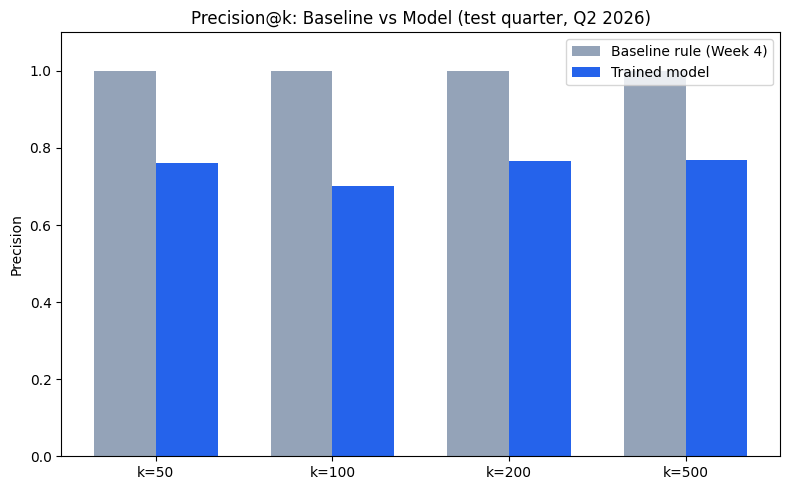

In [50]:
import matplotlib.pyplot as plt
import os

os.makedirs('work/outputs/figures', exist_ok=True)

k_values = [50, 100, 200, 500]
baseline_scores = [precision_at_k(test_features, 'baseline_score', 'needs_review', k=k) for k in k_values]
model_scores = [precision_at_k(test_features, 'model_score', 'needs_review', k=k) for k in k_values]

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(k_values))
width = 0.35

ax.bar([i - width/2 for i in x], baseline_scores, width, label='Baseline rule (Week 4)', color='#94a3b8')
ax.bar([i + width/2 for i in x], model_scores, width, label='Trained model', color='#2563eb')

ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in k_values])
ax.set_ylabel('Precision')
ax.set_title('Precision@k: Baseline vs Model (test quarter, Q2 2026)')
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('work/outputs/figures/precision_at_k.png', dpi=150)
plt.show()

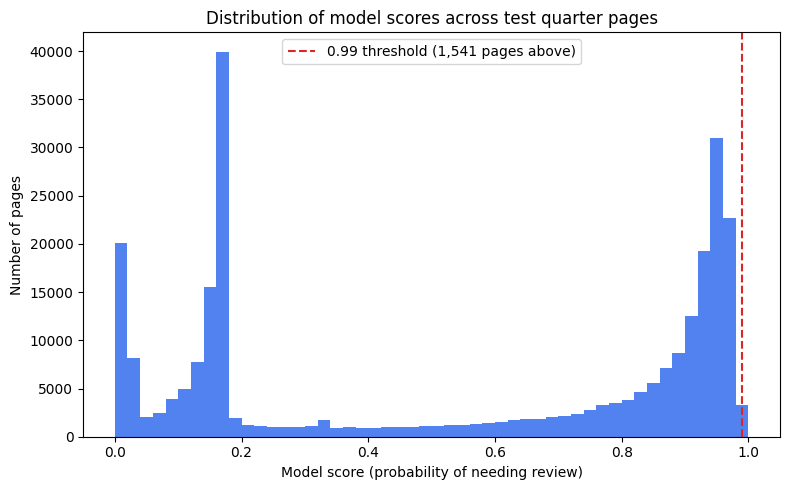

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(test_features['model_score'], bins=50, color='#2563eb', alpha=0.8)
ax.set_xlabel('Model score (probability of needing review)')
ax.set_ylabel('Number of pages')
ax.set_title('Distribution of model scores across test quarter pages')
ax.axvline(0.99, color='#dc2626', linestyle='--', label='0.99 threshold (1,541 pages above)')
ax.legend()

plt.tight_layout()
plt.savefig('work/outputs/figures/score_distribution.png', dpi=150)
plt.show()

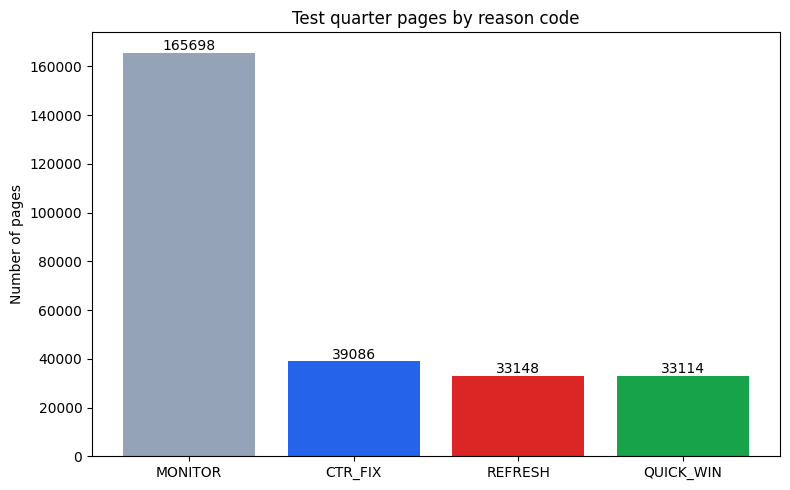

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = test_features['baseline_reason'].value_counts()
colors = {'MONITOR': '#94a3b8', 'CTR_FIX': '#2563eb', 'QUICK_WIN': '#16a34a', 'REFRESH': '#dc2626'}
bar_colors = [colors[c] for c in counts.index]

ax.bar(counts.index, counts.values, color=bar_colors)
ax.set_ylabel('Number of pages')
ax.set_title('Test quarter pages by reason code')

for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, str(v), ha='center')

plt.tight_layout()
plt.savefig('work/outputs/figures/reason_code_breakdown.png', dpi=150)
plt.show()



Three charts generated from the test quarter (Q2 2026), saved to `work/outputs/figures/`:

1. **`precision_at_k.png`** — Precision@k comparison, baseline rule vs. trained model, at k=50/100/200/500. Supports the Results section, alongside the honest caveat about baseline/label overlap.
2. **`score_distribution.png`** — Histogram of model confidence scores across all 271,046 test pages, showing the small cluster of saturated scores near 1.0 discussed in Section 6.
3. **`reason_code_breakdown.png`** — Count of pages by reason code (MONITOR, CTR_FIX, QUICK_WIN, REFRESH) in the test quarter, giving a sense of scale for the Recommendations section.

All three are referenced directly in the deployed paper's Results and Recommendations sections.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.